In [24]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from tqdm import tqdm
import matplotlib.pyplot as plt
from torchsummary import summary
import torchvision.transforms.functional as TF
import random
from PIL import Image
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.cuda.amp import autocast, GradScaler

In [ ]:
class AugmentedSegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None, augment_factor=3, augment_transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.augment_factor = augment_factor
        self.augment_transform = augment_transform
        self.images = os.listdir(image_dir)
        self.masks = os.listdir(mask_dir)
        
        self.cached_images = []
        self.cached_masks = []
        for f in self.filenames:
            img = cv2.imread(os.path.join(image_dir, f))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            mask = cv2.imread(os.path.join(mask_dir, f), 0)
            self.cached_images.append(img)
            self.cached_masks.append(mask)
        
        # Define Weather Augmentations
        self.weather_transform = A.Compose([
            A.OneOf([
                # RandomRain now uses brightness_coefficient
                A.RandomRain(brightness_coefficient=0.9, drop_width=1, blur_value=3, p=1),
        
                # RandomFog: fog_coef_lower/upper are now fog_coef_range (tuple)
                A.RandomFog(fog_coef_range=(0.3, 0.5), alpha_coef=0.08, p=1),
        
                # RandomSnow: snow_point_lower/upper are now snow_point_range (tuple)
                A.RandomSnow(brightness_coeff=2.5, snow_point_range=(0.3, 0.5), p=1),
        
                # A.Gamma has been renamed to A.RandomGamma
                A.RandomGamma(gamma_limit=(80, 120), p=1), 
            ], p=0.5), 
            A.CLAHE(p=0.5), # Crucial for visibility in Dust/Fog scenarios
        ])
        
    def __len__(self):
        return len(self.images) * (1 + self.augment_factor)

    def __getitem__(self, idx):
        image_idx = idx // (1 + self.augment_factor)
        img_path = os.path.join(self.image_dir, self.images[image_idx])
        mask_path = os.path.join(self.mask_dir, self.masks[image_idx])

        # 1. Load data as NumPy arrays
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, 0) # Grayscale

        # 2. Convert NumPy arrays to PIL Images
        image = Image.fromarray(image)
        mask = Image.fromarray(mask)
        
        # Determine if this is an augmented sample
        is_augmented = idx % (1 + self.augment_factor) != 0
        if is_augmented:

            # --- WEATHER AUGMENTATIONS (Implemented via Albumentations) ---
            # Convert to numpy for weather effects
            image_np = np.array(image)
            mask_np = np.array(mask)
        
            augmented = self.weather_transform(image=image_np, mask=mask_np)
            image = Image.fromarray(augmented['image'])
            mask = Image.fromarray(augmented['mask'])

            # --- GEOMETRIC AUGMENTATIONS (Must apply to BOTH Image and Mask) ---
            
            # Synchronized Horizontal Flip
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            # NEW: Random Rotation (e.g., -15 to 15 degrees)
            if random.random() > 0.5:
                angle = random.uniform(-15, 15)
                image = TF.rotate(image, angle)
                # Use NEAREST interpolation for masks to avoid creating fake class values
                mask = TF.rotate(mask, angle, interpolation=TF.InterpolationMode.NEAREST)

            # --- PHOTOMETRIC AUGMENTATIONS (Apply to IMAGE ONLY) ---
            
            # NEW: Random Color/Contrast Jitter
            if random.random() > 0.5:
                # brightness, contrast, saturation, hue
                color_jitter = transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
                image = color_jitter(image)

            # NEW: Random Gaussian Blur
            if random.random() > 0.3:
                # Using a small 3x3 kernel to simulate slight motion or focus blur
                image = TF.gaussian_blur(image, kernel_size=(3, 3))
        
        # 3. Resize
        image = TF.resize(image, (256, 256))
        mask = TF.resize(mask, (256, 256), interpolation=TF.InterpolationMode.NEAREST)

        # 4. Convert Image to Tensor and Normalize
        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

        # 5. Convert Mask to LongTensor for CrossEntropyLoss
        mask = torch.from_numpy(np.array(mask)).long()

        return image, mask

In [26]:
def prepare_dataloaders(image_dir, mask_dir, batch_size=32, val_ratio=0.2):
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    dataset = AugmentedSegmentationDataset(image_dir, mask_dir, transform=transform)
    val_size = int(len(dataset) * val_ratio)
    train_size = len(dataset) - val_size
    train_ds, val_ds = random_split(dataset, [train_size, val_size])
    
    train_loader = DataLoader(
    train_ds, 
    batch_size=32,       # Increased batch size for higher GPU usage
    shuffle=True, 
    num_workers=8,       # Parallel CPU processing
    pin_memory=True,     # Faster transfer to GPU
    prefetch_factor=2
    )
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


In [27]:
def calculate_iou(outputs, masks, num_classes):
    outputs = torch.argmax(outputs, dim=1)
    ious = []
    for cls in range(1, num_classes): # Skip background [cite: 570]
        pred = (outputs == cls)
        target = (masks == cls)
        intersection = (pred & target).sum().item()
        union = (pred | target).sum().item()
        if union > 0:
            ious.append(intersection / union)
    return np.mean(ious) if ious else 0.0

In [28]:
# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
num_classes = 16  # Based on HW2 spec
model = smp.Unet(
    encoder_name="resnet50",        # Upgrade to ResNet-34
    encoder_weights="imagenet",      # Use pre-trained weights
    in_channels=3,                  # RGB input
    classes=16,                     # Your 16 classes
    activation=None                 # Raw logits for CrossEntropyLoss
).to(device)
dice_loss = smp.losses.DiceLoss(mode='multiclass', classes=range(16))
ce_loss = nn.CrossEntropyLoss()
def criterion(outputs, targets):
    return ce_loss(outputs, targets) + dice_loss(outputs, targets)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

Using device: cuda


In [29]:
# Training
epochs = 10
scaler = GradScaler() # Required for Mixed Precision (AMP)
train_loss_history = []  # Added to track training loss 
val_loss_history = []    # Added to track validation loss [cite: 714, 716]
train_iou_history = []   # Added to track training IoU [cite: 714, 716]
val_iou_history = []     # Added to track validation IoU [cite: 715, 716]

base_path = os.path.abspath("./UAV_dataset/train")
img_dir = os.path.join(base_path, "imgs")
mask_dir = os.path.join(base_path, "masks")

train_loader, val_loader = prepare_dataloaders(img_dir, mask_dir)

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # Track total loss for the epoch [cite: 720]
    running_iou = 0.0  # Track total IoU for the epoch [cite: 721]
    
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() # Accumulate loss [cite: 735]
        running_iou += calculate_iou(outputs, masks, num_classes) # Accumulate IoU [cite: 738, 739]

    # Calculate and store epoch averages [cite: 741, 742, 743, 744]
    train_loss_history.append(running_loss / len(train_loader))
    train_iou_history.append(running_iou / len(train_loader))
        
    # Validation [cite: 750]
    model.eval()
    val_running_loss = 0.0 # Added to track validation loss [cite: 752]
    val_running_iou = 0.0  # Added to track validation IoU [cite: 754]
    
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            
            # Calculate metrics for the validation batch [cite: 759, 762]
            loss = criterion(outputs, masks)
            val_running_loss += loss.item()
            val_running_iou += calculate_iou(outputs, masks, num_classes)
    
    # Calculate and store validation averages [cite: 765, 766, 767, 768]
    val_loss_history.append(val_running_loss / len(val_loader))
    val_iou_history.append(val_running_iou / len(val_loader))
    scheduler.step(val_iou_history[-1])
    print(f"Mean IoU: {val_iou_history[-1]:.4f}")

# Save weights [cite: 777]
torch.save(model.state_dict(), "best_model.pth")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_44724\3430370556.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() # Required for Mixed Precision (AMP)


AttributeError: 'AugmentedSegmentationDataset' object has no attribute 'filenames'

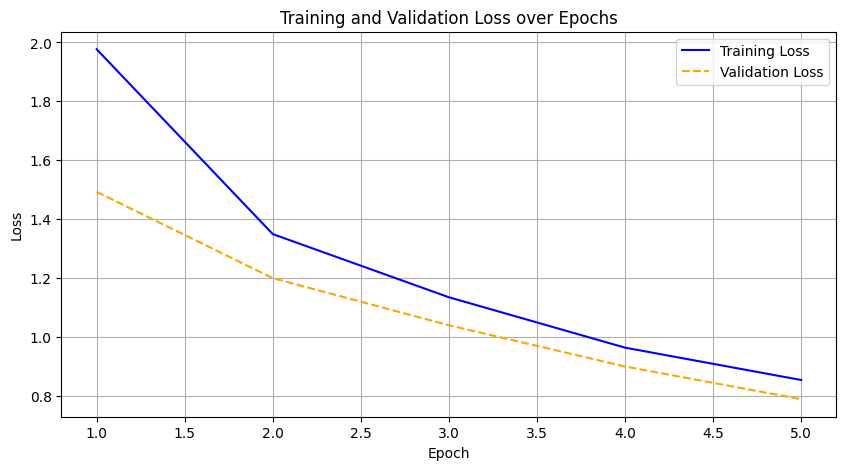

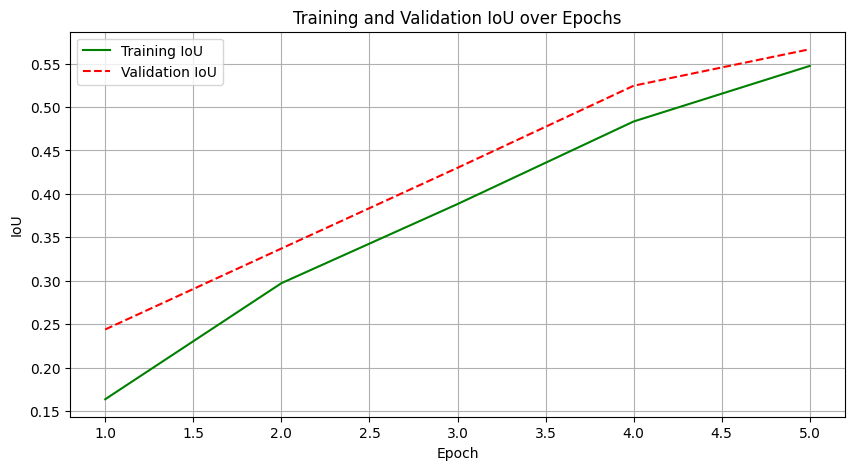

In [20]:
# ===== Plotting Training and Validation Loss =====
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_loss_history, label="Training Loss", color='blue')
plt.plot(range(1, epochs + 1), val_loss_history, label="Validation Loss", linestyle='--', color='orange')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss over Epochs")
plt.legend()
plt.grid(True)
plt.savefig('./loss.png') # Required for your 'fig' folder
plt.show()

# ===== Plotting Training and Validation IoU =====
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_iou_history, label="Training IoU", color='green')
plt.plot(range(1, epochs + 1), val_iou_history, label="Validation IoU", linestyle='--', color='red')
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Training and Validation IoU over Epochs")
plt.legend()
plt.grid(True)
plt.savefig('./iou.png') # Required for your 'fig' folder
plt.show()

In [21]:
# Setup
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [22]:
# Path settings
base_path2 = os.path.abspath("./UAV_dataset/test")
test_img_dir = os.path.join(base_path2, "imgs")
output_dir = os.path.join(base_path2, "masks")
os.makedirs(output_dir, exist_ok=True)

# 2. Run Inference
with torch.no_grad():
    for img_name in os.listdir(test_img_dir):
        # Load and preprocess
        img_path = os.path.join(test_img_dir, img_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Use the SAME transform you used in training (Resize to 256x256)
        input_tensor = transform(image).unsqueeze(0).to(device) 
        
        # Predict
        output = model(input_tensor)
        pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
        
        # 3. Save as grayscale image
        # Mask values are 0-15, which are very dark. You may want to save them as raw values.
        mask_img = Image.fromarray(pred_mask.astype(np.uint8))
        mask_img = mask_img.resize((800, 600), resample=Image.NEAREST) 
        mask_img.save(os.path.join(output_dir, img_name))

In [23]:
def rle_encode(mask):
    pixels = mask.flatten(order='F')
    pixels = np.concatenate([[0], pixels, [0]])  # padding
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[:-1:2]
    return ' '.join(str(x) for x in runs)

# 資料夾和輸出的csv存放路徑
mask_dir = os.path.join(base_path2, "masks")
output_csv = "sample_submission.csv"
num_classes = 16       # 0~15 類別

records = []

for fname in sorted(os.listdir(mask_dir)):
    if not fname.endswith(".png"):
        continue
    img_id = fname
    mask = cv2.imread(os.path.join(mask_dir, fname), cv2.IMREAD_GRAYSCALE)
    row = {"img": img_id}
    for class_id in range(num_classes):
        class_mask = (mask == class_id).astype(np.uint8)
        if class_mask.sum() == 0:
            row[f"class_{class_id}"] = "none"
        else:
            row[f"class_{class_id}"] = rle_encode(class_mask)
    records.append(row)

# 存成 CSV
df = pd.DataFrame(records)
df.to_csv(output_csv, index=False)
print(f"Saved to {output_csv}")

Saved to sample_submission.csv
